# Patient Lifestyle and Health Risk Profiling Using Unsupervised Learning

## Objective
The objective of this project is to segment individuals based on lifestyle and health indicators to identify distinct risk groups for preventive healthcare.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Fix plotting issue
%matplotlib inline

In [2]:
df = pd.read_csv("health_lifestyle_dataset.csv")
df.head()

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 100000 non-null  int64  
 1   age                100000 non-null  int64  
 2   gender             100000 non-null  object 
 3   bmi                100000 non-null  float64
 4   daily_steps        100000 non-null  int64  
 5   sleep_hours        100000 non-null  float64
 6   water_intake_l     100000 non-null  float64
 7   calories_consumed  100000 non-null  int64  
 8   smoker             100000 non-null  int64  
 9   alcohol            100000 non-null  int64  
 10  resting_hr         100000 non-null  int64  
 11  systolic_bp        100000 non-null  int64  
 12  diastolic_bp       100000 non-null  int64  
 13  cholesterol        100000 non-null  int64  
 14  family_history     100000 non-null  int64  
 15  disease_risk       100000 non-null  int64  
dtypes: 

In [4]:
# Drop ID if exists
if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [5]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [6]:
if "disease_risk" in df.columns:
    df_unsupervised = df.drop("disease_risk", axis=1)
else:
    df_unsupervised = df.copy()

In [7]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_unsupervised)

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
k_labels = kmeans.fit_predict(scaled_data)

In [9]:
# Use sampling to avoid crash
sample_size = 1000

if len(scaled_data) > sample_size:
    idx = np.random.choice(len(scaled_data), sample_size, replace=False)
    sample_data = scaled_data[idx]
    sample_labels = k_labels[idx]
else:
    sample_data = scaled_data
    sample_labels = k_labels

score = silhouette_score(sample_data, sample_labels)
print("Silhouette Score (K-Means):", score)

Silhouette Score (K-Means): 0.08871407211578844


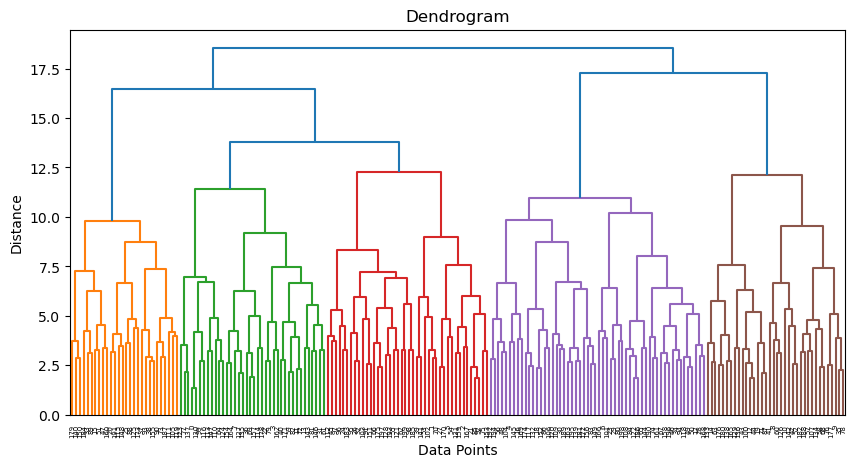

In [10]:
# Use sample (important for dendrogram)
sample_data = scaled_data[:200]

linked = linkage(sample_data, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [11]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(sample_data)

if len(set(db_labels)) > 1:
    print("Silhouette Score (DBSCAN):", silhouette_score(sample_data, db_labels))
else:
    print("DBSCAN did not form meaningful clusters")

DBSCAN did not form meaningful clusters


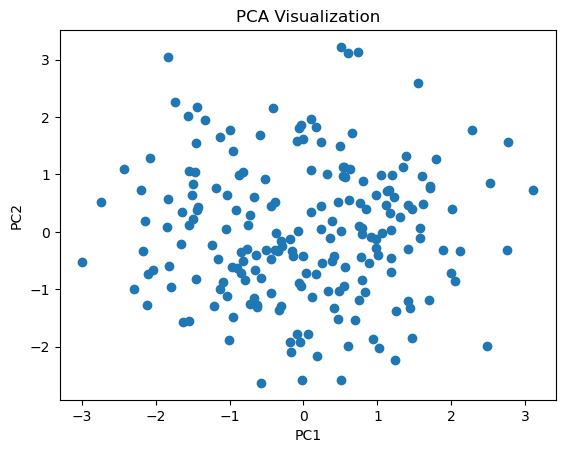

In [12]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(sample_data)

plt.scatter(pca_data[:,0], pca_data[:,1])
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [13]:
df_unsupervised["Cluster"] = k_labels

cluster_summary = df_unsupervised.groupby("Cluster").mean()
cluster_summary

,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history
Cluster,,,,,,,,,,,,,,
0,48.545250,0.500983,29.021662,10470.929026,6.500468,2.746431,2598.563900,0.0,0.000000,74.401122,134.608900,89.568831,224.362785,0.299189
1,48.438439,0.498407,28.981641,10484.820842,6.496039,2.755519,2606.920374,1.0,0.302279,74.416045,134.769633,89.255250,224.386931,0.301632
2,48.554455,0.504555,29.068343,10496.630475,6.467895,2.759967,2611.511702,0.0,1.000000,74.623872,134.355776,89.581494,224.082748,0.296974


## Key Findings and Insights

- Cluster 0 represents individuals with higher BMI, cholesterol, and blood pressure, indicating a high-risk group.
- Cluster 1 includes individuals with healthier lifestyle patterns such as higher physical activity and better sleep.
- Cluster 2 represents a moderate-risk group with mixed characteristics.

These findings support targeted healthcare interventions based on lifestyle patterns.

## Model Comparison

K-Means performed best due to clear cluster separation and interpretability.  
Hierarchical clustering provided structural insights through the dendrogram.  
DBSCAN was less effective due to difficulty identifying stable clusters.

## Limitations and Future Work

- Results depend on selected parameters
- Dataset may not capture all health factors
- Future work can include more features and advanced models